# Generative AI - Assignment 1
**Name:** Muhammad Nouman Hanif
**Roll Number:** 24K-8001

---
This notebook contains the complete code for all four parts of the assignment, running experiments on both MNIST and CIFAR-10 datasets for comparison.

### **Setup: Installing Required Libraries**
This cell ensures all necessary libraries are installed.

In [1]:
# Install required libraries
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install matplotlib pandas scikit-learn torchmetrics[image] torch-fidelity

Looking in indexes: https://download.pytorch.org/whl/cu118
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 26.0 MB/s eta 0:00:00


In [2]:
# Import libraries
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
from torch.utils.data import TensorDataset
from tqdm import tqdm

# Create a directory to save generated images
os.makedirs("generated_images", exist_ok=True)

/usr/local/lib/python3.12/dist-packages/torch_xla/experimental/gru.py:113: SyntaxWarning: invalid escape sequence '\_'
  * **h_n**: tensor of shape :math:`(D * \text{num\_layers}, H_{out})` or


---
## **Part 1: Exploratory Data Analysis (EDA)**
In this part, we will load and visualize the MNIST and CIFAR-10 datasets to understand their structure and complexity.

--- 1. Setting up parameters and device ---
Using device: cpu

--- 2. Loading and Visualizing Datasets ---


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 505kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.71MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 21.6MB/s]


MNIST dataset loaded: 60000 samples (padded to 32x32).
Number of classes: 10


100%|██████████| 170M/170M [00:04<00:00, 42.0MB/s]


CIFAR-10 dataset loaded: 50000 samples (32x32).
Number of classes: 10

--- 3. Displaying sample images ---


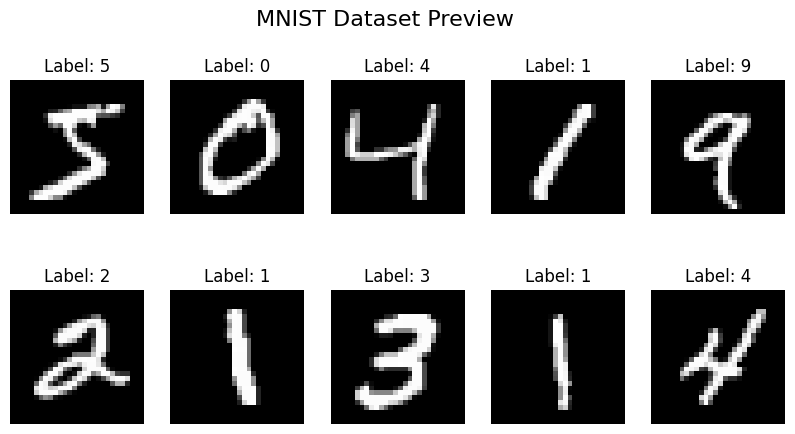

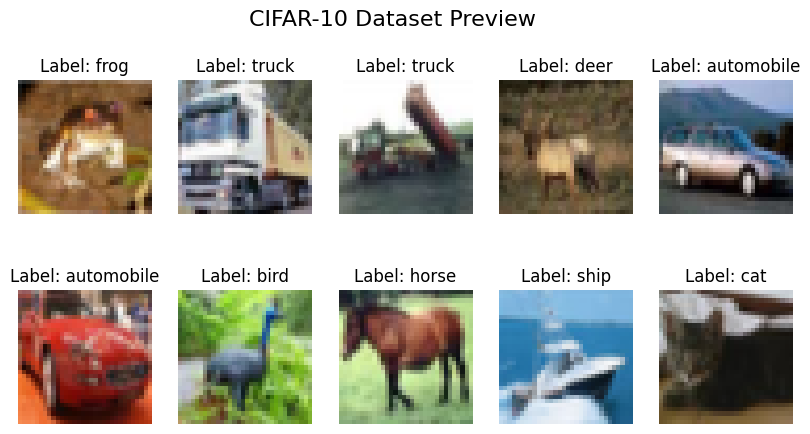

In [3]:
# --- 1. Setting up parameters and device ---
print("--- 1. Setting up parameters and device ---")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# --- 2. Loading and Visualizing Datasets ---
print("\n--- 2. Loading and Visualizing Datasets ---")

# MNIST - We pad to 32x32 to match CIFAR-10 and use a consistent architecture.
transform_mnist = transforms.Compose([
    transforms.Pad(2), # Pad from 28x28 to 32x32
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
mnist_dataset = datasets.MNIST(root="dataset/", train=True, transform=transform_mnist, download=True)
mnist_loader = DataLoader(mnist_dataset, batch_size=128, shuffle=True, drop_last=True)
print(f"MNIST dataset loaded: {len(mnist_dataset)} samples (padded to 32x32).")
print(f"Number of classes: {len(mnist_dataset.classes)}")

# CIFAR-10
transform_cifar = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
cifar_dataset = datasets.CIFAR10(root="dataset/", train=True, transform=transform_cifar, download=True)
cifar_loader = DataLoader(cifar_dataset, batch_size=128, shuffle=True, drop_last=True)
print(f"CIFAR-10 dataset loaded: {len(cifar_dataset)} samples (32x32).")
print(f"Number of classes: {len(cifar_dataset.classes)}")

# --- 3. Displaying sample images ---
print("\n--- 3. Displaying sample images ---")

# Display MNIST
plt.figure(figsize=(10, 5))
plt.suptitle("MNIST Dataset Preview", fontsize=16)
# We need to un-normalize and remove padding for display
unpad_mnist_data = [mnist_dataset[i][0].squeeze()[2:-2, 2:-2] for i in range(10)]
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(unpad_mnist_data[i], cmap='gray')
    plt.title(f"Label: {mnist_dataset.targets[i]}")
    plt.axis('off')
plt.savefig("generated_images/part1_mnist_preview.png")
plt.show()


# Display CIFAR-10
plt.figure(figsize=(10, 5))
plt.suptitle("CIFAR-10 Dataset Preview", fontsize=16)
cifar_images_for_plot = cifar_dataset.data[:10]
cifar_labels_for_plot = [cifar_dataset.classes[label] for label in cifar_dataset.targets[:10]]
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(cifar_images_for_plot[i])
    plt.title(f"Label: {cifar_labels_for_plot[i]}")
    plt.axis('off')
plt.savefig("generated_images/part1_cifar10_preview.png")
plt.show()

---
## **Part 2: Generative Adversarial Networks (GANs)**
In this part, we will implement and train a GAN and a Conditional GAN (CGAN) on both MNIST and CIFAR-10 to compare their performance.

### **2.1 - FID and KID Evaluation**
Here we add the quantitative evaluation of the generated images.

In [4]:
def calculate_fid_kid_gan(generator, dataset, z_dim, device, num_images=1000, is_mnist=False, conditional_class=None, embed_size=100):
    """
    Helper function to calculate FID and KID scores for GANs and CGANs.
    """
    generator.eval()

    # Initialize metrics
    fid = FrechetInceptionDistance(normalize=True).to(device)
    kid = KernelInceptionDistance(subset_size=100, normalize=True).to(device)

    if conditional_class is not None:
        class_indices = [i for i, label in enumerate(dataset.targets) if label == conditional_class]
        class_dataset = torch.utils.data.Subset(dataset, class_indices)
        real_loader = DataLoader(class_dataset, batch_size=BATCH_SIZE, shuffle=True)
    else:
        real_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

    # Generate fake images
    fake_images = []
    with torch.no_grad():
        for _ in tqdm(range(num_images // BATCH_SIZE), desc="Generating Fake Images"):
            noise = torch.randn(BATCH_SIZE, z_dim, 1, 1).to(device)
            if conditional_class is not None:
                labels = (torch.ones(BATCH_SIZE) * conditional_class).long().to(device)
                fake_batch = generator(noise, labels)
            else:
                fake_batch = generator(noise)

            if is_mnist:
                fake_batch = fake_batch.repeat(1, 3, 1, 1)
            fake_images.append(fake_batch)
    fake_images = torch.cat(fake_images, 0)

    fid.update(fake_images, real=False)
    kid.update(fake_images, real=False)

    # Process real images
    real_images_processed = 0
    for real_batch, _ in tqdm(real_loader, desc="Processing Real Images"):
        if real_images_processed >= num_images:
            break
        real_batch = real_batch.to(device)
        if is_mnist:
            real_batch = real_batch.repeat(1, 3, 1, 1)

        fid.update(real_batch, real=True)
        kid.update(real_batch, real=True)
        real_images_processed += real_batch.shape[0]

    fid_score = fid.compute()
    kid_mean, kid_std = kid.compute()

    return fid_score, kid_mean, kid_std

### **2.2.1 - GAN Architecture for 32x32 Images**

In [5]:
# --- GAN Implementation for 32x32 Images ---
# Hyperparameters
Z_DIM = 100
FEATURES_DISC = 64
FEATURES_GEN = 64
NUM_EPOCHS = 25
LR = 2e-4
BATCH_SIZE = 128
YOUR_DIGIT = 1 # Based on Roll Number 24K-8001
YOUR_CIFAR_CLASS = 1 # Automobile
CHANNELS_IMG_MNIST = 1
CHANNELS_IMG_CIFAR = 3

# --- New GAN Architecture for 32x32 ---
class Discriminator32(nn.Module):
    def __init__(self, channels_img, features_d):
        super(Discriminator32, self).__init__()
        self.disc = nn.Sequential(
            # Input: N x C x 32 x 32
            nn.Conv2d(channels_img, features_d, kernel_size=4, stride=2, padding=1), # 16x16
            nn.LeakyReLU(0.2),
            self._block(features_d, features_d * 2, 4, 2, 1), # 8x8
            self._block(features_d * 2, features_d * 4, 4, 2, 1), # 4x4
            nn.Conv2d(features_d * 4, 1, kernel_size=4, stride=1, padding=0), # 1x1
            nn.Sigmoid(),
        )

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2),
        )

    def forward(self, x):
        return self.disc(x)

class Generator32(nn.Module):
    def __init__(self, z_dim, channels_img, features_g):
        super(Generator32, self).__init__()
        self.gen = nn.Sequential(
            # Input: N x z_dim x 1 x 1
            self._block(z_dim, features_g * 8, 4, 1, 0), # 4x4
            self._block(features_g * 8, features_g * 4, 4, 2, 1), # 8x8
            self._block(features_g * 4, features_g * 2, 4, 2, 1), # 16x16
            nn.ConvTranspose2d(features_g * 2, channels_img, kernel_size=4, stride=2, padding=1), # 32x32
            nn.Tanh(),
        )

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.gen(x)

def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.BatchNorm2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)

### **2.2.2 - GAN on MNIST**


--- Starting DCGAN Training on MNIST ---
Epoch [1/25] Loss D: 0.3913, Loss G: 2.0043
Epoch [2/25] Loss D: 0.4301, Loss G: 1.1347
Epoch [3/25] Loss D: 0.5298, Loss G: 1.1281
Epoch [4/25] Loss D: 0.5284, Loss G: 1.2479
Epoch [5/25] Loss D: 0.5087, Loss G: 1.0820
Epoch [6/25] Loss D: 0.5130, Loss G: 1.0927
Epoch [7/25] Loss D: 0.6272, Loss G: 0.5087
Epoch [8/25] Loss D: 0.4990, Loss G: 1.1830
Epoch [9/25] Loss D: 0.4707, Loss G: 1.5905
Epoch [10/25] Loss D: 0.4527, Loss G: 1.3576
Epoch [11/25] Loss D: 0.4815, Loss G: 1.4732
Epoch [12/25] Loss D: 0.4778, Loss G: 1.0122
Epoch [13/25] Loss D: 0.4532, Loss G: 1.0422
Epoch [14/25] Loss D: 0.4452, Loss G: 1.0759
Epoch [15/25] Loss D: 0.4429, Loss G: 1.3719
Epoch [16/25] Loss D: 0.6494, Loss G: 0.8008
Epoch [17/25] Loss D: 0.6530, Loss G: 2.2501
Epoch [18/25] Loss D: 0.4530, Loss G: 1.5479
Epoch [19/25] Loss D: 0.5361, Loss G: 2.2884
Epoch [20/25] Loss D: 0.5012, Loss G: 2.1484
Epoch [21/25] Loss D: 0.4420, Loss G: 1.4468
Epoch [22/25] Loss D: 

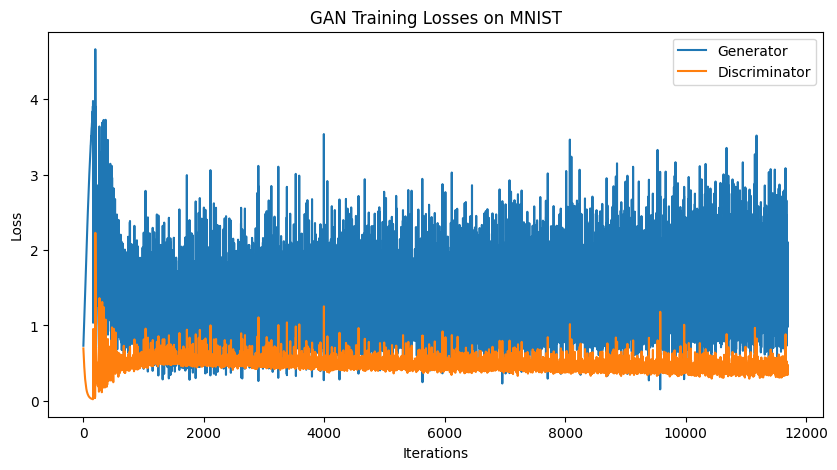

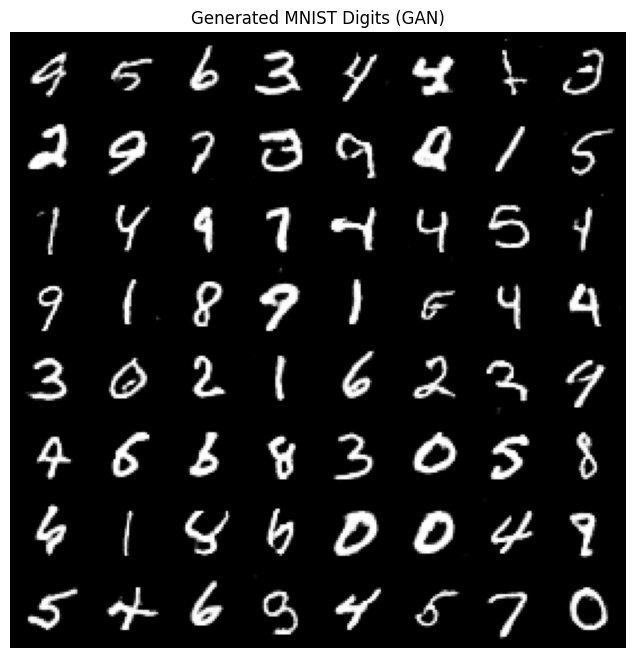


--- Evaluating MNIST GAN ---


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 408MB/s]
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
Processing Real Images:   2%|▏         | 8/469 [00:09<09:09,  1.19s/it]


MNIST GAN -> FID: 24.2590
MNIST GAN -> KID Mean: 0.0123, KID Std: 0.0031
MNIST DCGAN models saved.


In [ ]:
# GAN Training on MNIST
print("\n--- Starting DCGAN Training on MNIST ---")
gen_mnist = Generator32(Z_DIM, CHANNELS_IMG_MNIST, FEATURES_GEN).to(device)
disc_mnist = Discriminator32(CHANNELS_IMG_MNIST, FEATURES_DISC).to(device)
initialize_weights(gen_mnist)
initialize_weights(disc_mnist)

opt_gen = optim.Adam(gen_mnist.parameters(), lr=LR, betas=(0.5, 0.999))
opt_disc = optim.Adam(disc_mnist.parameters(), lr=LR, betas=(0.5, 0.999))
criterion = nn.BCELoss()

fixed_noise = torch.randn(64, Z_DIM, 1, 1).to(device)
gen_losses, disc_losses = [], []

gen_mnist.train()
disc_mnist.train()

for epoch in range(NUM_EPOCHS):
    for batch_idx, (real, _) in enumerate(mnist_loader):
        real = real.to(device)
        noise = torch.randn(BATCH_SIZE, Z_DIM, 1, 1).to(device)
        fake = gen_mnist(noise)

        # Train Discriminator
        disc_real = disc_mnist(real).reshape(-1)
        loss_disc_real = criterion(disc_real, torch.ones_like(disc_real))
        disc_fake = disc_mnist(fake.detach()).reshape(-1)
        loss_disc_fake = criterion(disc_fake, torch.zeros_like(disc_fake))
        loss_disc = (loss_disc_real + loss_disc_fake) / 2
        disc_mnist.zero_grad()
        loss_disc.backward()
        opt_disc.step()

        # Train Generator
        output = disc_mnist(fake).reshape(-1)
        loss_gen = criterion(output, torch.ones_like(output))
        gen_mnist.zero_grad()
        loss_gen.backward()
        opt_gen.step()

        gen_losses.append(loss_gen.item())
        disc_losses.append(loss_disc.item())

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Loss D: {loss_disc:.4f}, Loss G: {loss_gen:.4f}")

# Plot losses
plt.figure(figsize=(10, 5))
plt.title("GAN Training Losses on MNIST")
plt.plot(gen_losses, label="Generator")
plt.plot(disc_losses, label="Discriminator")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.savefig("generated_images/part2_gan_loss_mnist.png")
plt.show()

# Generate and save images
gen_mnist.eval()
with torch.no_grad():
    fake_images = gen_mnist(fixed_noise).detach().cpu()
    img_grid = torchvision.utils.make_grid(fake_images, normalize=True)
    plt.figure(figsize=(8, 8))
    plt.imshow(np.transpose(img_grid, (1, 2, 0))[:,:,0], cmap='gray') # Display as grayscale
    plt.title("Generated MNIST Digits (GAN)")
    plt.axis("off")
    plt.savefig("generated_images/part2_gan_generated_mnist.png")
    plt.show()

# --- Evaluate MNIST GAN ---
print("\n--- Evaluating MNIST GAN ---")
fid_mnist, kid_mean_mnist, kid_std_mnist = calculate_fid_kid_gan(gen_mnist, mnist_dataset, Z_DIM, device, is_mnist=True)
print(f"MNIST GAN -> FID: {fid_mnist.item():.4f}")
print(f"MNIST GAN -> KID Mean: {kid_mean_mnist.item():.4f}, KID Std: {kid_std_mnist.item():.4f}")

# Save models
torch.save(gen_mnist.state_dict(), "gan_generator_mnist.pth")
torch.save(disc_mnist.state_dict(), "gan_discriminator_mnist.pth")
print("MNIST DCGAN models saved.")

### **2.2.3 - GAN on CIFAR-10**


--- Starting DCGAN Training on CIFAR-10 ---
Epoch [1/25] Loss D: 0.4992, Loss G: 1.3896
Epoch [2/25] Loss D: 0.4520, Loss G: 1.7719
Epoch [3/25] Loss D: 0.4753, Loss G: 1.4615
Epoch [4/25] Loss D: 0.4362, Loss G: 1.8708
Epoch [5/25] Loss D: 0.4304, Loss G: 1.2564
Epoch [6/25] Loss D: 0.5073, Loss G: 1.1600
Epoch [7/25] Loss D: 0.4725, Loss G: 1.2357
Epoch [8/25] Loss D: 0.4739, Loss G: 1.2396
Epoch [9/25] Loss D: 0.4523, Loss G: 1.3493
Epoch [10/25] Loss D: 0.4640, Loss G: 1.4649
Epoch [11/25] Loss D: 0.4706, Loss G: 1.8650
Epoch [12/25] Loss D: 0.4272, Loss G: 0.9764
Epoch [13/25] Loss D: 0.5039, Loss G: 1.4585
Epoch [14/25] Loss D: 0.5708, Loss G: 0.5447
Epoch [15/25] Loss D: 0.3877, Loss G: 1.4186
Epoch [16/25] Loss D: 0.3912, Loss G: 1.3648
Epoch [17/25] Loss D: 0.4437, Loss G: 1.8013
Epoch [18/25] Loss D: 0.3747, Loss G: 1.6517
Epoch [19/25] Loss D: 0.4769, Loss G: 1.6842
Epoch [20/25] Loss D: 0.4129, Loss G: 1.2551
Epoch [21/25] Loss D: 0.6064, Loss G: 1.1194
Epoch [22/25] Loss 

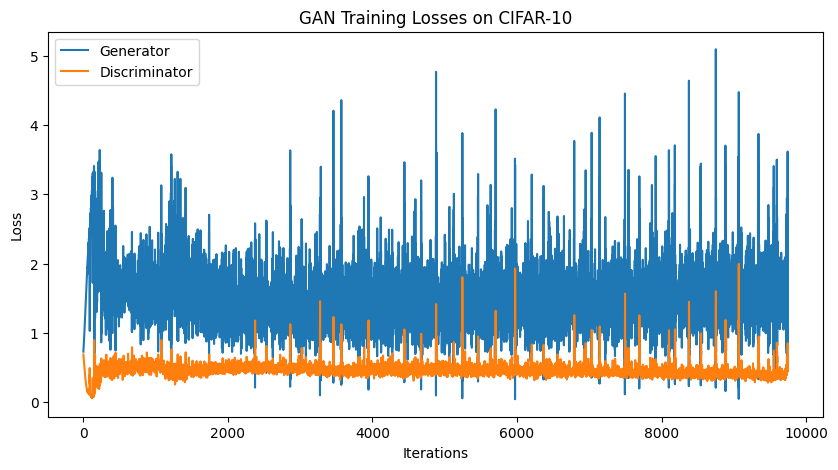

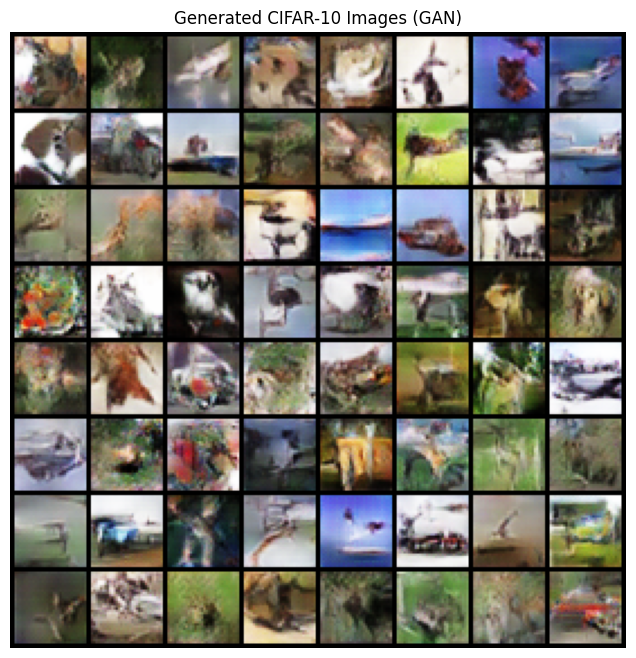


--- Evaluating CIFAR-10 GAN ---


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 403MB/s]
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
Processing Real Images:   2%|▏         | 8/391 [01:22<1:05:55, 10.33s/it]


CIFAR-10 GAN -> FID: 70.1384
CIFAR-10 GAN -> KID Mean: 0.0263, KID Std: 0.0052
CIFAR-10 DCGAN models saved.


In [6]:
# GAN Training on CIFAR-10
print("\n--- Starting DCGAN Training on CIFAR-10 ---")
gen_cifar = Generator32(Z_DIM, CHANNELS_IMG_CIFAR, FEATURES_GEN).to(device)
disc_cifar = Discriminator32(CHANNELS_IMG_CIFAR, FEATURES_DISC).to(device)
initialize_weights(gen_cifar)
initialize_weights(disc_cifar)

opt_gen_cifar = optim.Adam(gen_cifar.parameters(), lr=LR, betas=(0.5, 0.999))
opt_disc_cifar = optim.Adam(disc_cifar.parameters(), lr=LR, betas=(0.5, 0.999))
criterion_cifar = nn.BCELoss()

fixed_noise_cifar = torch.randn(64, Z_DIM, 1, 1).to(device)
gen_losses_cifar, disc_losses_cifar = [], []

gen_cifar.train()
disc_cifar.train()

for epoch in range(NUM_EPOCHS):
    for batch_idx, (real, _) in enumerate(cifar_loader):
        real = real.to(device)
        noise = torch.randn(BATCH_SIZE, Z_DIM, 1, 1).to(device)
        fake = gen_cifar(noise)

        # Train Discriminator
        disc_real = disc_cifar(real).reshape(-1)
        loss_disc_real = criterion_cifar(disc_real, torch.ones_like(disc_real))
        disc_fake = disc_cifar(fake.detach()).reshape(-1)
        loss_disc_fake = criterion_cifar(disc_fake, torch.zeros_like(disc_fake))
        loss_disc = (loss_disc_real + loss_disc_fake) / 2
        disc_cifar.zero_grad()
        loss_disc.backward()
        opt_disc_cifar.step()

        # Train Generator
        output = disc_cifar(fake).reshape(-1)
        loss_gen = criterion_cifar(output, torch.ones_like(output))
        gen_cifar.zero_grad()
        loss_gen.backward()
        opt_gen_cifar.step()

        gen_losses_cifar.append(loss_gen.item())
        disc_losses_cifar.append(loss_disc.item())

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Loss D: {loss_disc:.4f}, Loss G: {loss_gen:.4f}")

# Plot losses
plt.figure(figsize=(10, 5))
plt.title("GAN Training Losses on CIFAR-10")
plt.plot(gen_losses_cifar, label="Generator")
plt.plot(disc_losses_cifar, label="Discriminator")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.savefig("generated_images/part2_gan_loss_cifar10.png")
plt.show()

# Generate and save images
gen_cifar.eval()
with torch.no_grad():
    fake_images = gen_cifar(fixed_noise_cifar).detach().cpu()
    img_grid = torchvision.utils.make_grid(fake_images, normalize=True)
    plt.figure(figsize=(8, 8))
    plt.imshow(np.transpose(img_grid, (1, 2, 0)))
    plt.title("Generated CIFAR-10 Images (GAN)")
    plt.axis("off")
    plt.savefig("generated_images/part2_gan_generated_cifar10.png")
    plt.show()

# --- Evaluate CIFAR-10 GAN ---
print("\n--- Evaluating CIFAR-10 GAN ---")
fid_cifar, kid_mean_cifar, kid_std_cifar = calculate_fid_kid_gan(gen_cifar, cifar_dataset, Z_DIM, device, is_mnist=False)
print(f"CIFAR-10 GAN -> FID: {fid_cifar.item():.4f}")
print(f"CIFAR-10 GAN -> KID Mean: {kid_mean_cifar.item():.4f}, KID Std: {kid_std_cifar.item():.4f}")

# Save models
torch.save(gen_cifar.state_dict(), "gan_generator_cifar10.pth")
torch.save(disc_cifar.state_dict(), "gan_discriminator_cifar10.pth")
print("CIFAR-10 DCGAN models saved.")

### **2.3.1 - Conditional GAN Architecture for 32x32 Images**

In [ ]:
# --- CGAN Implementation for 32x32 Images ---
NUM_CLASSES = 10
EMBED_SIZE = 100
IMG_SIZE = 32
CHANNELS_IMG_CIFAR = 3
CHANNELS_IMG_MNIST = 1
criterion = nn.BCELoss()

class Discriminator_CGAN32(nn.Module):
    def __init__(self, channels_img, features_d, num_classes, img_size):
        super(Discriminator_CGAN32, self).__init__()
        self.img_size = img_size
        self.embed = nn.Embedding(num_classes, img_size * img_size)
        self.disc = nn.Sequential(
            nn.Conv2d(channels_img + 1, features_d, kernel_size=4, stride=2, padding=1), # 16x16
            nn.LeakyReLU(0.2),
            self._block(features_d, features_d * 2, 4, 2, 1), # 8x8
            self._block(features_d*2, features_d * 4, 4, 2, 1), # 4x4
            nn.Conv2d(features_d * 4, 1, kernel_size=4, stride=1, padding=0), # 1x1
            nn.Sigmoid(),
        )

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2),
        )

    def forward(self, x, labels):
        embedding = self.embed(labels).view(labels.shape[0], 1, self.img_size, self.img_size)
        x = torch.cat([x, embedding], dim=1)
        return self.disc(x)

class Generator_CGAN32(nn.Module):
    def __init__(self, z_dim, channels_img, features_g, num_classes, embed_size):
        super(Generator_CGAN32, self).__init__()
        self.gen = nn.Sequential(
            self._block(z_dim + embed_size, features_g * 8, 4, 1, 0),
            self._block(features_g * 8, features_g * 4, 4, 2, 1),
            self._block(features_g * 4, features_g * 2, 4, 2, 1),
            nn.ConvTranspose2d(features_g * 2, channels_img, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),
        )
        self.embed = nn.Embedding(num_classes, embed_size)

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
        )

    def forward(self, x, labels):
        embedding = self.embed(labels).unsqueeze(2).unsqueeze(3)
        x = torch.cat([x, embedding], dim=1)
        return self.gen(x)

### **2.3.2 - CGAN on MNIST**
Now we generate a specific digit '1'.


--- Starting CGAN Training on MNIST ---
Epoch [1/25] Loss D: 0.4516, Loss G: 1.0144
Epoch [2/25] Loss D: 0.3849, Loss G: 1.5842
Epoch [3/25] Loss D: 0.3085, Loss G: 2.1851
Epoch [4/25] Loss D: 0.4126, Loss G: 1.4829
Epoch [5/25] Loss D: 0.2238, Loss G: 2.4043
Epoch [6/25] Loss D: 0.3748, Loss G: 2.3209
Epoch [7/25] Loss D: 0.1652, Loss G: 2.7782
Epoch [8/25] Loss D: 0.1933, Loss G: 2.5653
Epoch [9/25] Loss D: 0.1256, Loss G: 3.8231
Epoch [10/25] Loss D: 0.1007, Loss G: 2.9546
Epoch [11/25] Loss D: 0.0866, Loss G: 3.4136
Epoch [12/25] Loss D: 0.0706, Loss G: 3.4148
Epoch [13/25] Loss D: 0.2283, Loss G: 3.7113
Epoch [14/25] Loss D: 0.1515, Loss G: 3.6563
Epoch [15/25] Loss D: 0.1989, Loss G: 4.0027
Epoch [16/25] Loss D: 0.1957, Loss G: 1.8763
Epoch [17/25] Loss D: 0.0335, Loss G: 3.6921
Epoch [18/25] Loss D: 0.3285, Loss G: 3.0856
Epoch [19/25] Loss D: 0.1020, Loss G: 3.9223
Epoch [20/25] Loss D: 0.1387, Loss G: 3.7140
Epoch [21/25] Loss D: 0.0806, Loss G: 3.6638
Epoch [22/25] Loss D: 0

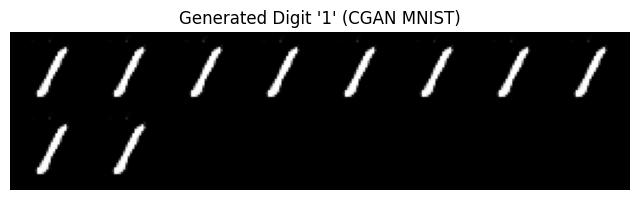


--- Evaluating MNIST CGAN ---


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:01<00:00, 95.1MB/s]
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
Processing Real Images:  15%|█▌        | 8/53 [00:10<00:56,  1.26s/it]


MNIST CGAN (Digit 1) -> FID: 198.6063
MNIST CGAN (Digit 1) -> KID Mean: 0.2535, KID Std: 0.0102
MNIST CGAN models saved.


In [ ]:
# CGAN Training on MNIST
print("\n--- Starting CGAN Training on MNIST ---")
gen_cgan_mnist = Generator_CGAN32(Z_DIM, CHANNELS_IMG_MNIST, FEATURES_GEN, NUM_CLASSES, EMBED_SIZE).to(device)
disc_cgan_mnist = Discriminator_CGAN32(CHANNELS_IMG_MNIST, FEATURES_DISC, NUM_CLASSES, IMG_SIZE).to(device)
initialize_weights(gen_cgan_mnist)
initialize_weights(disc_cgan_mnist)

opt_gen_cgan = optim.Adam(gen_cgan_mnist.parameters(), lr=LR, betas=(0.5, 0.999))
opt_disc_cgan = optim.Adam(disc_cgan_mnist.parameters(), lr=LR, betas=(0.5, 0.999))

gen_cgan_mnist.train()
disc_cgan_mnist.train()

for epoch in range(NUM_EPOCHS):
    for batch_idx, (real, labels) in enumerate(mnist_loader):
        real, labels = real.to(device), labels.to(device)
        noise = torch.randn(BATCH_SIZE, Z_DIM, 1, 1).to(device)
        fake = gen_cgan_mnist(noise, labels)

        # Train Discriminator
        disc_real = disc_cgan_mnist(real, labels).reshape(-1)
        loss_disc_real = criterion(disc_real, torch.ones_like(disc_real))
        disc_fake = disc_cgan_mnist(fake.detach(), labels).reshape(-1)
        loss_disc_fake = criterion(disc_fake, torch.zeros_like(disc_fake))
        loss_disc = (loss_disc_real + loss_disc_fake) / 2
        disc_cgan_mnist.zero_grad()
        loss_disc.backward()
        opt_disc_cgan.step()

        # Train Generator
        output = disc_cgan_mnist(fake, labels).reshape(-1)
        loss_gen = criterion(output, torch.ones_like(output))
        gen_cgan_mnist.zero_grad()
        loss_gen.backward()
        opt_gen_cgan.step()

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Loss D: {loss_disc:.4f}, Loss G: {loss_gen:.4f}")

# Generate specific digit
gen_cgan_mnist.eval()
with torch.no_grad():
    noise = torch.randn(10, Z_DIM, 1, 1).to(device)
    labels = torch.ones(10).long().to(device) * YOUR_DIGIT
    fake_images = gen_cgan_mnist(noise, labels).detach().cpu()
    img_grid = torchvision.utils.make_grid(fake_images, normalize=True)
    plt.figure(figsize=(8, 8))
    plt.imshow(np.transpose(img_grid, (1, 2, 0))[:,:,0], cmap='gray')
    plt.title(f"Generated Digit '{YOUR_DIGIT}' (CGAN MNIST)")
    plt.axis("off")
    plt.savefig(f"generated_images/part2_cgan_generated_digit_{YOUR_DIGIT}.png")
    plt.show()


# --- Evaluate MNIST CGAN ---
print("\n--- Evaluating MNIST CGAN ---")
fid_cgan_mnist, kid_mean_cgan_mnist, kid_std_cgan_mnist = calculate_fid_kid_gan(
    gen_cgan_mnist, mnist_dataset, Z_DIM, device, is_mnist=True, conditional_class=YOUR_DIGIT, embed_size=EMBED_SIZE
)
print(f"MNIST CGAN (Digit {YOUR_DIGIT}) -> FID: {fid_cgan_mnist.item():.4f}")
print(f"MNIST CGAN (Digit {YOUR_DIGIT}) -> KID Mean: {kid_mean_cgan_mnist.item():.4f}, KID Std: {kid_std_cgan_mnist.item():.4f}")

# Save models
torch.save(gen_cgan_mnist.state_dict(), "cgan_generator_mnist.pth")
torch.save(disc_cgan_mnist.state_dict(), "cgan_discriminator_mnist.pth")
print("MNIST CGAN models saved.")



### **2.3.3 - CGAN on CIFAR-10**



--- Starting CGAN Training on CIFAR-10 ---
Epoch [1/25] Loss D: 0.5811, Loss G: 1.2395
Epoch [2/25] Loss D: 0.5364, Loss G: 1.4714
Epoch [3/25] Loss D: 0.4992, Loss G: 1.3836
Epoch [4/25] Loss D: 0.5828, Loss G: 1.3257
Epoch [5/25] Loss D: 0.5209, Loss G: 1.5760
Epoch [6/25] Loss D: 0.3674, Loss G: 1.9874
Epoch [7/25] Loss D: 0.3517, Loss G: 2.3335
Epoch [8/25] Loss D: 0.5427, Loss G: 1.5490
Epoch [9/25] Loss D: 0.2427, Loss G: 2.6784
Epoch [10/25] Loss D: 0.3350, Loss G: 2.2973
Epoch [11/25] Loss D: 0.2717, Loss G: 2.4000
Epoch [12/25] Loss D: 0.3376, Loss G: 1.9549
Epoch [13/25] Loss D: 0.2361, Loss G: 2.4153
Epoch [14/25] Loss D: 0.2457, Loss G: 2.3190
Epoch [15/25] Loss D: 0.2945, Loss G: 2.2858
Epoch [16/25] Loss D: 0.2284, Loss G: 2.6051
Epoch [17/25] Loss D: 0.2534, Loss G: 2.5053
Epoch [18/25] Loss D: 0.2947, Loss G: 2.6825
Epoch [19/25] Loss D: 0.2093, Loss G: 2.5240
Epoch [20/25] Loss D: 0.4073, Loss G: 3.6093
Epoch [21/25] Loss D: 0.2974, Loss G: 2.0306
Epoch [22/25] Loss D

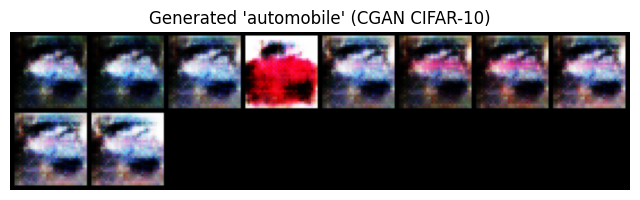


--- Evaluating CIFAR-10 CGAN ---


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 414MB/s]
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
Processing Real Images:  20%|██        | 8/40 [00:10<00:40,  1.26s/it]


CIFAR-10 CGAN (automobile) -> FID: 241.9636
CIFAR-10 CGAN (automobile) -> KID Mean: 0.2554, KID Std: 0.0103
CIFAR-10 CGAN models saved.


In [ ]:
# CGAN Training on CIFAR-10
print("\n--- Starting CGAN Training on CIFAR-10 ---")
gen_cgan_cifar = Generator_CGAN32(Z_DIM, CHANNELS_IMG_CIFAR, FEATURES_GEN, NUM_CLASSES, EMBED_SIZE).to(device)
disc_cgan_cifar = Discriminator_CGAN32(CHANNELS_IMG_CIFAR, FEATURES_DISC, NUM_CLASSES, IMG_SIZE).to(device)
initialize_weights(gen_cgan_cifar)
initialize_weights(disc_cgan_cifar)

opt_gen_cgan_cifar = optim.Adam(gen_cgan_cifar.parameters(), lr=LR, betas=(0.5, 0.999))
opt_disc_cgan_cifar = optim.Adam(disc_cgan_cifar.parameters(), lr=LR, betas=(0.5, 0.999))

gen_cgan_cifar.train()
disc_cgan_cifar.train()

for epoch in range(NUM_EPOCHS):
    for batch_idx, (real, labels) in enumerate(cifar_loader):
        real, labels = real.to(device), labels.to(device)
        noise = torch.randn(BATCH_SIZE, Z_DIM, 1, 1).to(device)
        fake = gen_cgan_cifar(noise, labels)

        # Train Discriminator
        disc_real = disc_cgan_cifar(real, labels).reshape(-1)
        loss_disc_real = criterion(disc_real, torch.ones_like(disc_real))
        disc_fake = disc_cgan_cifar(fake.detach(), labels).reshape(-1)
        loss_disc_fake = criterion(disc_fake, torch.zeros_like(disc_fake))
        loss_disc = (loss_disc_real + loss_disc_fake) / 2
        disc_cgan_cifar.zero_grad()
        loss_disc.backward()
        opt_disc_cgan_cifar.step()

        # Train Generator
        output = disc_cgan_cifar(fake, labels).reshape(-1)
        loss_gen = criterion(output, torch.ones_like(output))
        gen_cgan_cifar.zero_grad()
        loss_gen.backward()
        opt_gen_cgan_cifar.step()

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Loss D: {loss_disc:.4f}, Loss G: {loss_gen:.4f}")

# Generate specific class
gen_cgan_cifar.eval()
with torch.no_grad():
    noise = torch.randn(10, Z_DIM, 1, 1).to(device)
    labels = torch.ones(10).long().to(device) * YOUR_CIFAR_CLASS
    fake_images = gen_cgan_cifar(noise, labels).detach().cpu()
    img_grid = torchvision.utils.make_grid(fake_images, normalize=True)
    plt.figure(figsize=(8, 8))
    plt.imshow(np.transpose(img_grid, (1, 2, 0)))
    class_name = cifar_dataset.classes[YOUR_CIFAR_CLASS]
    plt.title(f"Generated '{class_name}' (CGAN CIFAR-10)")
    plt.axis("off")
    plt.savefig(f"generated_images/part2_cgan_generated_{class_name}.png")
    plt.show()

# --- Evaluate CIFAR-10 CGAN ---
print("\n--- Evaluating CIFAR-10 CGAN ---")
fid_cgan_cifar, kid_mean_cgan_cifar, kid_std_cgan_cifar = calculate_fid_kid_gan(
    gen_cgan_cifar, cifar_dataset, Z_DIM, device, is_mnist=False, conditional_class=YOUR_CIFAR_CLASS, embed_size=EMBED_SIZE
)
print(f"CIFAR-10 CGAN ({class_name}) -> FID: {fid_cgan_cifar.item():.4f}")
print(f"CIFAR-10 CGAN ({class_name}) -> KID Mean: {kid_mean_cgan_cifar.item():.4f}, KID Std: {kid_std_cgan_cifar.item():.4f}")


# Save models
torch.save(gen_cgan_cifar.state_dict(), "cgan_generator_cifar10.pth")
torch.save(disc_cgan_cifar.state_dict(), "cgan_discriminator_cifar10.pth")
print("CIFAR-10 CGAN models saved.")

---
## **Part 3: Variational Autoencoders (VAEs)**
In this part, we implement a VAE and train it on both MNIST and CIFAR-10.

### **3.1 - FID and KID Evaluation**
Here we add the quantitative evaluation of the generated images.



In [ ]:
# --- VAE Evaluation ---
def calculate_fid_kid_vae(vae_model, dataset, latent_dim, device, num_images=1000, is_mnist=False):
    """
    Helper function to calculate FID and KID scores for VAEs.
    """
    vae_model.eval()

    fid = FrechetInceptionDistance(normalize=True).to(device)
    kid = KernelInceptionDistance(subset_size=100, normalize=True).to(device)
    real_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

    # Generate fake images from random latent vectors
    fake_images = []
    with torch.no_grad():
        for _ in tqdm(range(num_images // BATCH_SIZE), desc="Generating Fake Images (VAE)"):
            z = torch.randn(BATCH_SIZE, latent_dim).to(device)
            fake_batch = vae_model.decoder(vae_model.decoder_fc(z))
            if is_mnist:
                fake_batch = fake_batch.repeat(1, 3, 1, 1)
            fake_images.append(fake_batch)
    fake_images = torch.cat(fake_images, 0)

    fid.update(fake_images, real=False)
    kid.update(fake_images, real=False)

    # Process real images
    real_images_processed = 0
    for real_batch, _ in tqdm(real_loader, desc="Processing Real Images"):
        if real_images_processed >= num_images:
            break
        real_batch = real_batch.to(device)
        if is_mnist:
            real_batch = real_batch.repeat(1, 3, 1, 1)

        fid.update(real_batch, real=True)
        kid.update(real_batch, real=True)
        real_images_processed += real_batch.shape[0]

    fid_score = fid.compute()
    kid_mean, kid_std = kid.compute()

    return fid_score, kid_mean, kid_std

### **3.2 - VAE Architecture for 32x32 Images**

In [ ]:
# --- VAE Implementation for 32x32 ---
# Hyperparameters
BATCH_SIZE = 128
LATENT_DIM = 20
CHANNELS_IMG_MNIST = 1
CHANNELS_IMG_CIFAR = 3
YOUR_DIGIT = 1 # Based on Roll Number 24K-8001
class VAE32(nn.Module):
    def __init__(self, in_channels, latent_dim):
        super(VAE32, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=4, stride=2, padding=1), # 16x16
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # 8x8
            nn.ReLU(),
            nn.Flatten(),
        )
        self.fc_mu = nn.Linear(64*8*8, latent_dim)
        self.fc_logvar = nn.Linear(64*8*8, latent_dim)

        # Decoder
        self.decoder_fc = nn.Linear(latent_dim, 64*8*8)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, 8, 8)),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), # 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(32, in_channels, kernel_size=4, stride=2, padding=1), # 32x32
            nn.Sigmoid() # Use Sigmoid for normalized data [0,1]
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(self.decoder_fc(z)), mu, logvar

def vae_loss_function(recon_x, x, mu, logvar):
    # For BCE, input should be in [0,1], so we un-normalize
    x_unnorm = x * 0.5 + 0.5
    BCE = nn.functional.binary_cross_entropy(recon_x, x_unnorm, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

### **3.3 - VAE on MNIST**


--- Starting VAE Training on MNIST ---
Epoch [1/20] VAE Loss: 120.9429
Epoch [2/20] VAE Loss: 112.6250
Epoch [3/20] VAE Loss: 110.1537
Epoch [4/20] VAE Loss: 107.8496
Epoch [5/20] VAE Loss: 107.4749
Epoch [6/20] VAE Loss: 101.4060
Epoch [7/20] VAE Loss: 103.1842
Epoch [8/20] VAE Loss: 103.2601
Epoch [9/20] VAE Loss: 102.1773
Epoch [10/20] VAE Loss: 104.3883
Epoch [11/20] VAE Loss: 100.1690
Epoch [12/20] VAE Loss: 104.3389
Epoch [13/20] VAE Loss: 100.8530
Epoch [14/20] VAE Loss: 101.9936
Epoch [15/20] VAE Loss: 103.5085
Epoch [16/20] VAE Loss: 100.9358
Epoch [17/20] VAE Loss: 98.0284
Epoch [18/20] VAE Loss: 101.4068
Epoch [19/20] VAE Loss: 103.5376
Epoch [20/20] VAE Loss: 99.0201


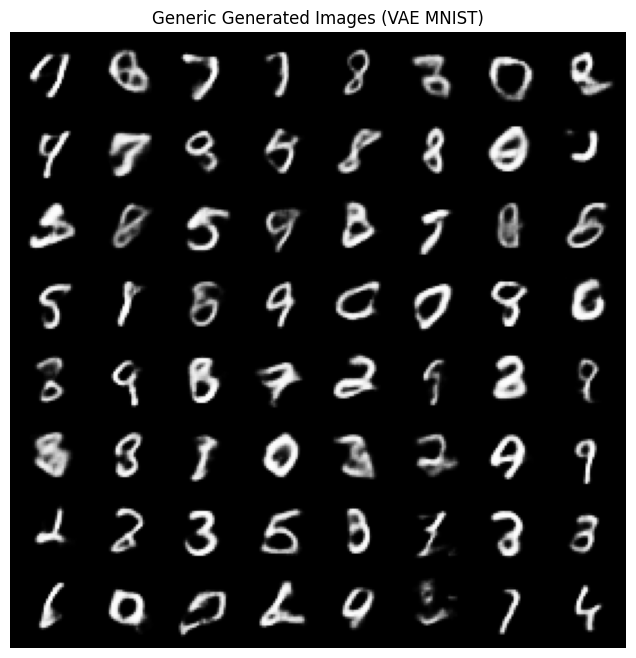


--- Conditional Generation for Digit 1 (VAE MNIST) ---


/tmp/ipython-input-1559061394.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  digit_indices = (torch.tensor(mnist_dataset.targets) == YOUR_DIGIT).nonzero().squeeze()


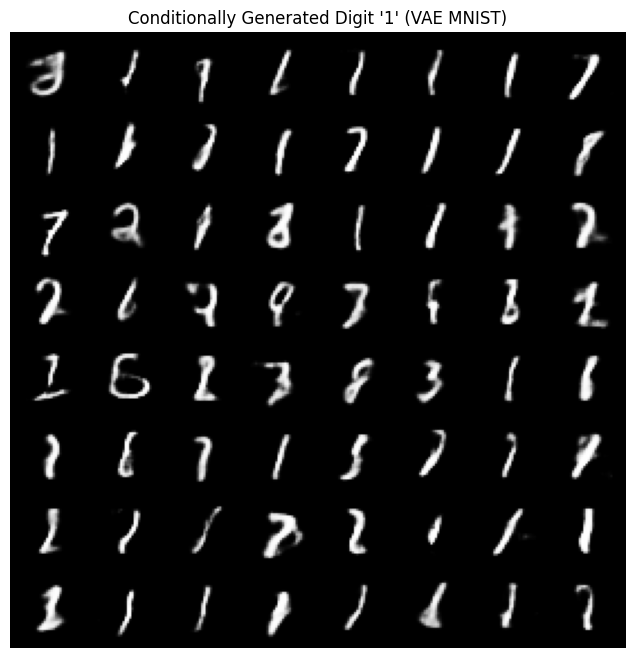


--- Visualizing MNIST Latent Space ---


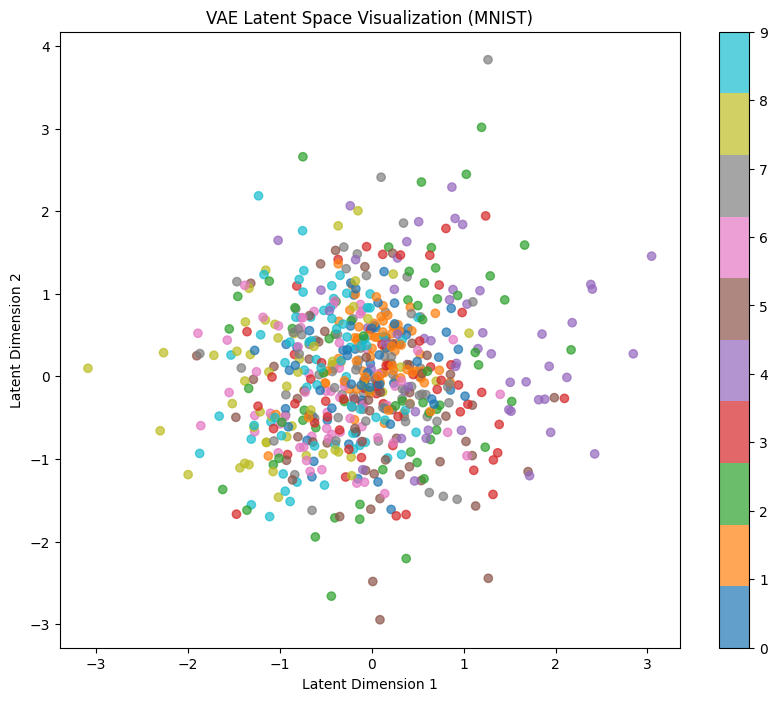


--- Evaluating MNIST VAE ---


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 383MB/s]
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
Processing Real Images:   2%|▏         | 8/469 [00:09<09:09,  1.19s/it]


MNIST VAE -> FID: 88.3460
MNIST VAE -> KID Mean: 0.0708, KID Std: 0.0054
MNIST VAE model saved.


In [ ]:
# VAE Training on MNIST
print("\n--- Starting VAE Training on MNIST ---")
vae_mnist = VAE32(CHANNELS_IMG_MNIST, LATENT_DIM).to(device)
optimizer_vae = optim.Adam(vae_mnist.parameters(), lr=1e-3)

vae_mnist.train()
for epoch in range(20): # VAEs often converge faster
    for batch_idx, (data, _) in enumerate(mnist_loader):
        data = data.to(device)
        recon_batch, mu, logvar = vae_mnist(data)
        loss = vae_loss_function(recon_batch, data, mu, logvar)
        optimizer_vae.zero_grad()
        loss.backward()
        optimizer_vae.step()
    print(f"Epoch [{epoch+1}/20] VAE Loss: {loss.item() / len(data):.4f}")

# Generic Generation
vae_mnist.eval()
with torch.no_grad():
    z = torch.randn(64, LATENT_DIM).to(device)
    sample = vae_mnist.decoder(vae_mnist.decoder_fc(z)).cpu()
    img_grid = torchvision.utils.make_grid(sample, normalize=True)
    plt.figure(figsize=(8, 8))
    plt.imshow(np.transpose(img_grid, (1, 2, 0))[:,:,0], cmap='gray')
    plt.title("Generic Generated Images (VAE MNIST)")
    plt.axis("off")
    plt.savefig("generated_images/part3_vae_generic_images_mnist.png")
    plt.show()

# Conditional Generation
print("\n--- Conditional Generation for Digit 1 (VAE MNIST) ---")
digit_indices = (torch.tensor(mnist_dataset.targets) == YOUR_DIGIT).nonzero().squeeze()
digit_data = torch.stack([mnist_dataset[i][0] for i in digit_indices[:1000]]).to(device) # Use a subset for efficiency
with torch.no_grad():
    h = vae_mnist.encoder(digit_data)
    mu, _ = vae_mnist.fc_mu(h), vae_mnist.fc_logvar(h)
    mean_mu = mu.mean(dim=0)
    z = torch.randn(64, LATENT_DIM).to(device) + mean_mu
    sample = vae_mnist.decoder(vae_mnist.decoder_fc(z)).cpu()
    img_grid = torchvision.utils.make_grid(sample, normalize=True)
    plt.figure(figsize=(8, 8))
    plt.imshow(np.transpose(img_grid, (1, 2, 0))[:,:,0], cmap='gray')
    plt.title(f"Conditionally Generated Digit '{YOUR_DIGIT}' (VAE MNIST)")
    plt.axis("off")
    plt.savefig(f"generated_images/part3_vae_conditional_digit_{YOUR_DIGIT}.png")
    plt.show()

# Latent Space Visualization
print("\n--- Visualizing MNIST Latent Space ---")
vae_mnist.eval()
latent_vectors = []
labels_list = []
with torch.no_grad():
    # Use a smaller subset for faster plotting
    for i in range(5): # 5 batches
      data, labels = next(iter(mnist_loader))
      data = data.to(device)
      h = vae_mnist.encoder(data)
      mu, _ = vae_mnist.fc_mu(h), vae_mnist.fc_logvar(h)
      latent_vectors.append(mu.cpu())
      labels_list.append(labels.cpu())

latent_vectors = torch.cat(latent_vectors).numpy()
labels_list = torch.cat(labels_list).numpy()

plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_vectors[:, 0], latent_vectors[:, 1], c=labels_list, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, ticks=range(10))
plt.title('VAE Latent Space Visualization (MNIST)')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.savefig("generated_images/part3_vae_latent_space_mnist.png")
plt.show()

print("\n--- Evaluating MNIST VAE ---")
fid_vae_mnist, kid_mean_vae_mnist, kid_std_vae_mnist = calculate_fid_kid_vae(
    vae_mnist, mnist_dataset, LATENT_DIM, device, is_mnist=True
)
print(f"MNIST VAE -> FID: {fid_vae_mnist.item():.4f}")
print(f"MNIST VAE -> KID Mean: {kid_mean_vae_mnist.item():.4f}, KID Std: {kid_std_vae_mnist.item():.4f}")

# Save model
torch.save(vae_mnist.state_dict(), "vae_mnist.pth")
print("MNIST VAE model saved.")



### **3.4 - VAE on CIFAR-10**


--- Starting VAE Training on CIFAR-10 ---
Epoch [1/20] VAE Loss: 1856.1506
Epoch [2/20] VAE Loss: 1839.8807
Epoch [3/20] VAE Loss: 1842.8105
Epoch [4/20] VAE Loss: 1869.2317
Epoch [5/20] VAE Loss: 1841.8835
Epoch [6/20] VAE Loss: 1810.8792
Epoch [7/20] VAE Loss: 1814.9476
Epoch [8/20] VAE Loss: 1841.3549
Epoch [9/20] VAE Loss: 1804.7610
Epoch [10/20] VAE Loss: 1802.5166
Epoch [11/20] VAE Loss: 1828.5270
Epoch [12/20] VAE Loss: 1839.4305
Epoch [13/20] VAE Loss: 1820.6906
Epoch [14/20] VAE Loss: 1820.4796
Epoch [15/20] VAE Loss: 1858.7117
Epoch [16/20] VAE Loss: 1817.1310
Epoch [17/20] VAE Loss: 1846.0070
Epoch [18/20] VAE Loss: 1870.4674
Epoch [19/20] VAE Loss: 1813.3596
Epoch [20/20] VAE Loss: 1824.1539


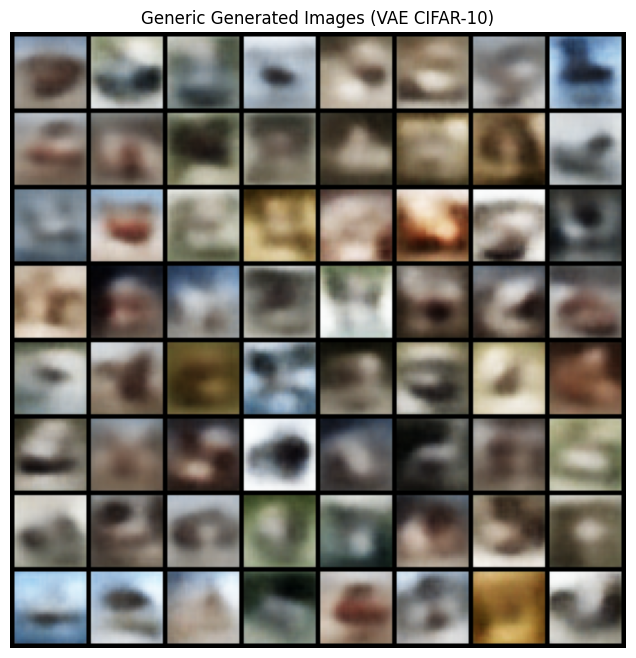


--- Conditional Generation for Class 'automobile' (VAE CIFAR-10) ---


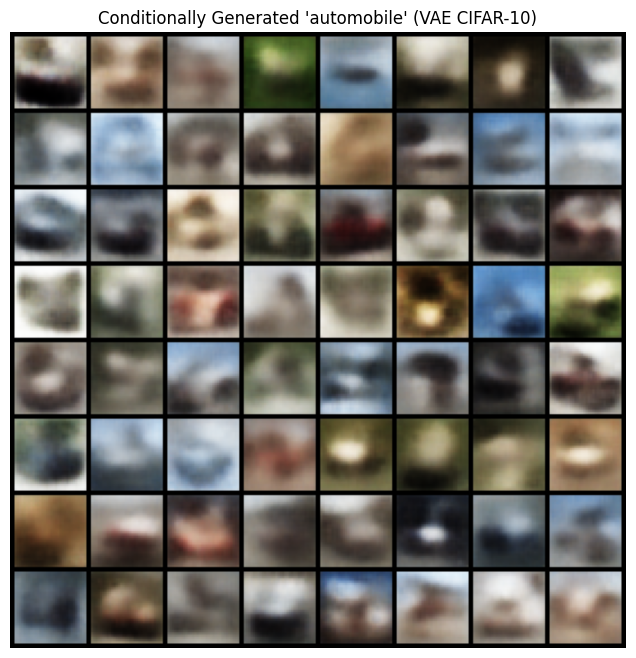


--- Visualizing CIFAR-10 Latent Space ---


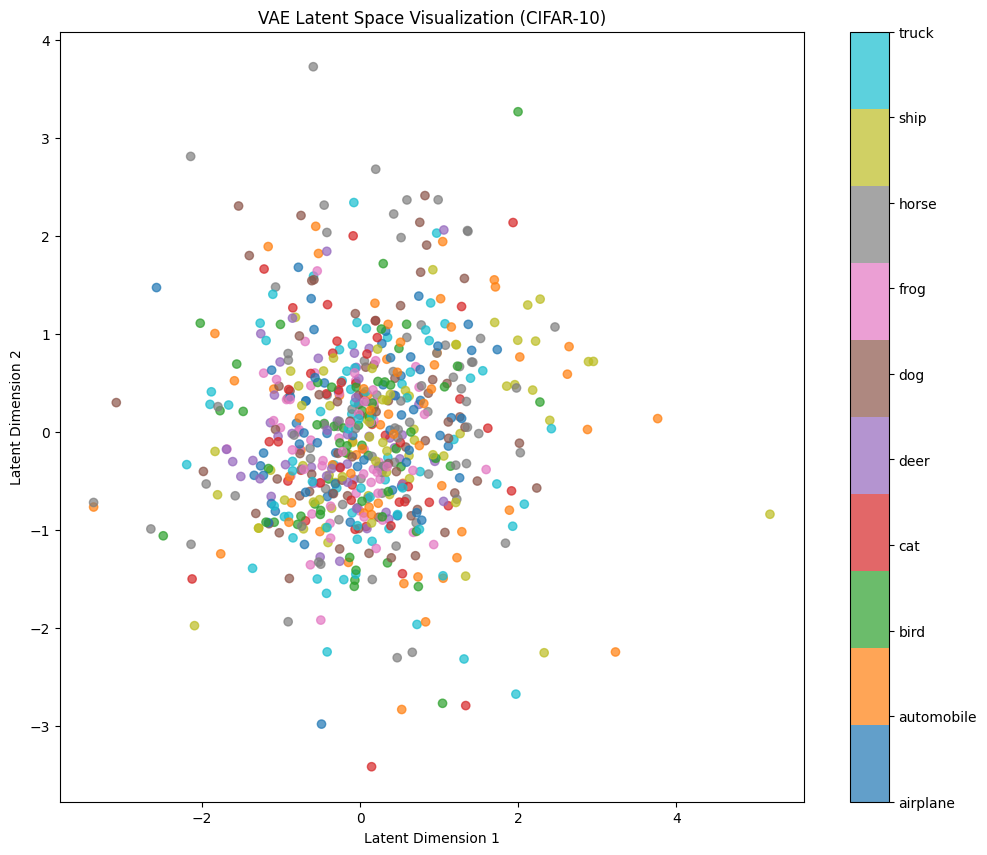


--- Evaluating CIFAR-10 VAE ---


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 379MB/s]
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
Processing Real Images:   2%|▏         | 8/391 [00:09<07:37,  1.20s/it]


CIFAR-10 VAE -> FID: 296.0481
CIFAR-10 VAE -> KID Mean: 0.2716, KID Std: 0.0107
CIFAR-10 VAE model saved.


In [ ]:
# VAE Training on CIFAR-10
print("\n--- Starting VAE Training on CIFAR-10 ---")
vae_cifar = VAE32(CHANNELS_IMG_CIFAR, LATENT_DIM).to(device)
optimizer_vae_cifar = optim.Adam(vae_cifar.parameters(), lr=1e-3)

vae_cifar.train()
for epoch in range(20):
    for batch_idx, (data, _) in enumerate(cifar_loader):
        data = data.to(device)
        recon_batch, mu, logvar = vae_cifar(data)
        loss = vae_loss_function(recon_batch, data, mu, logvar)
        optimizer_vae_cifar.zero_grad()
        loss.backward()
        optimizer_vae_cifar.step()
    print(f"Epoch [{epoch+1}/20] VAE Loss: {loss.item() / len(data):.4f}")

# Generic Generation
vae_cifar.eval()
with torch.no_grad():
    z = torch.randn(64, LATENT_DIM).to(device)
    sample = vae_cifar.decoder(vae_cifar.decoder_fc(z)).cpu()
    img_grid = torchvision.utils.make_grid(sample, normalize=True)
    plt.figure(figsize=(8, 8))
    plt.imshow(np.transpose(img_grid, (1, 2, 0)))
    plt.title("Generic Generated Images (VAE CIFAR-10)")
    plt.axis("off")
    plt.savefig("generated_images/part3_vae_generic_images_cifar10.png")
    plt.show()

# Conditional Generation
class_name = cifar_dataset.classes[YOUR_CIFAR_CLASS]
print(f"\n--- Conditional Generation for Class '{class_name}' (VAE CIFAR-10) ---")
class_indices = (torch.tensor(cifar_dataset.targets) == YOUR_CIFAR_CLASS).nonzero().squeeze()
class_data = torch.stack([cifar_dataset[i][0] for i in class_indices[:1000]]).to(device)
with torch.no_grad():
    h = vae_cifar.encoder(class_data)
    mu, _ = vae_cifar.fc_mu(h), vae_cifar.fc_logvar(h)
    mean_mu = mu.mean(dim=0)
    z = torch.randn(64, LATENT_DIM).to(device) + mean_mu
    sample = vae_cifar.decoder(vae_cifar.decoder_fc(z)).cpu()
    img_grid = torchvision.utils.make_grid(sample, normalize=True)
    plt.figure(figsize=(8, 8))
    plt.imshow(np.transpose(img_grid, (1, 2, 0)))
    plt.title(f"Conditionally Generated '{class_name}' (VAE CIFAR-10)")
    plt.axis("off")
    plt.savefig(f"generated_images/part3_vae_conditional_class_{class_name}.png")
    plt.show()

# Latent Space Visualization
print("\n--- Visualizing CIFAR-10 Latent Space ---")
vae_cifar.eval()
latent_vectors_cifar = []
labels_list_cifar = []
with torch.no_grad():
    for i in range(5):
      data, labels = next(iter(cifar_loader))
      data = data.to(device)
      h = vae_cifar.encoder(data)
      mu, _ = vae_cifar.fc_mu(h), vae_cifar.fc_logvar(h)
      latent_vectors_cifar.append(mu.cpu())
      labels_list_cifar.append(labels.cpu())

latent_vectors_cifar = torch.cat(latent_vectors_cifar).numpy()
labels_list_cifar = torch.cat(labels_list_cifar).numpy()

plt.figure(figsize=(12, 10))
scatter = plt.scatter(latent_vectors_cifar[:, 0], latent_vectors_cifar[:, 1], c=labels_list_cifar, cmap='tab10', alpha=0.7)
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_ticklabels(cifar_dataset.classes)
plt.title('VAE Latent Space Visualization (CIFAR-10)')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.savefig("generated_images/part3_vae_latent_space_cifar10.png")
plt.show()

# --- VAE Evaluation ---
print("\n--- Evaluating CIFAR-10 VAE ---")
fid_vae_cifar, kid_mean_vae_cifar, kid_std_vae_cifar = calculate_fid_kid_vae(
    vae_cifar, cifar_dataset, LATENT_DIM, device, is_mnist=False
)
print(f"CIFAR-10 VAE -> FID: {fid_vae_cifar.item():.4f}")
print(f"CIFAR-10 VAE -> KID Mean: {kid_mean_vae_cifar.item():.4f}, KID Std: {kid_std_vae_cifar.item():.4f}")


# Save model
torch.save(vae_cifar.state_dict(), "vae_cifar10.pth")
print("CIFAR-10 VAE model saved.")


---
## **Part 4: Anomaly Detection with VAE**
This part is a standalone application using a VAE for credit card fraud detection.


--- Part 4: Anomaly Detection using VAE ---

--- Training Anomaly Detection VAE ---
Epoch [1/10], Loss: 28.5416
Epoch [2/10], Loss: 16.4787
Epoch [3/10], Loss: 15.3722
Epoch [4/10], Loss: 20.0583
Epoch [5/10], Loss: 40.5467
Epoch [6/10], Loss: 21.6959
Epoch [7/10], Loss: 14.3979
Epoch [8/10], Loss: 18.8048
Epoch [9/10], Loss: 22.8081
Epoch [10/10], Loss: 16.2525


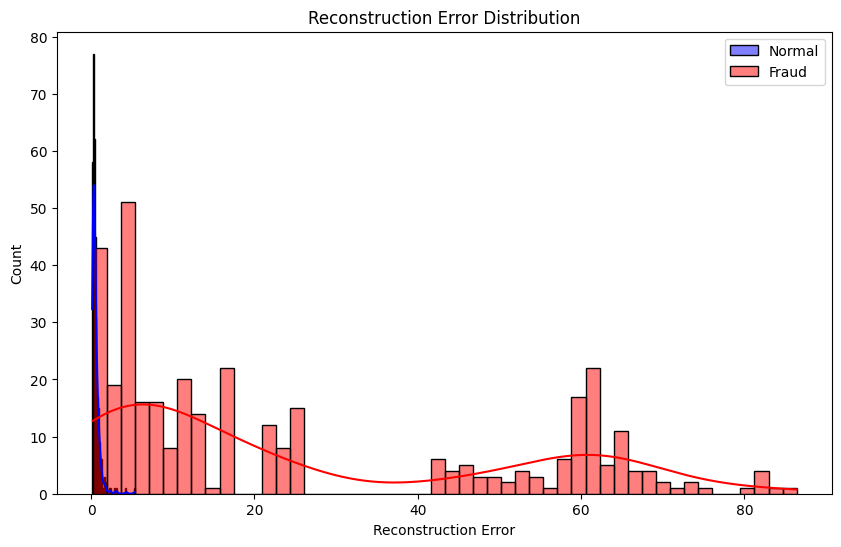


Classification Report:
              precision    recall  f1-score   support

      Normal       0.91      0.95      0.93       358
       Fraud       0.95      0.91      0.93       358

    accuracy                           0.93       716
   macro avg       0.93      0.93      0.93       716
weighted avg       0.93      0.93      0.93       716



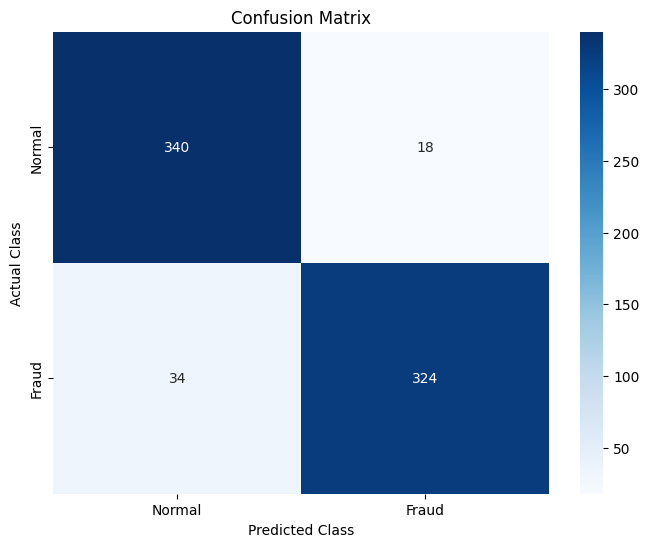

In [ ]:
# --- Data Loading ---
print("\n--- Part 4: Anomaly Detection using VAE ---")
file_path = 'creditcard.csv'
if not os.path.exists(file_path):
    print(f"Error: '{file_path}' not found. Please download from Kaggle and place in directory.")
else:
    data = pd.read_csv(file_path)
    scaler = StandardScaler()
    data['scaled_amount'] = scaler.fit_transform(data['Amount'].values.reshape(-1, 1))
    data['scaled_time'] = scaler.fit_transform(data['Time'].values.reshape(-1, 1))
    data = data.drop(['Time', 'Amount'], axis=1)

    normal_data = data[data['Class'] == 0]
    fraud_data = data[data['Class'] == 1]
    X_train = normal_data.drop('Class', axis=1).values
    X_test = pd.concat([normal_data.sample(n=len(fraud_data), random_state=42), fraud_data]).drop('Class', axis=1).values
    y_test = np.concatenate([np.zeros(len(fraud_data)), np.ones(len(fraud_data))])

    train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32))
    ad_train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
    test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32))
    ad_test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

    # --- Anomaly Detection VAE Model ---
    class TabularVAE(nn.Module):
        def __init__(self, input_dim, hidden_dim, latent_dim):
            super(TabularVAE, self).__init__()
            self.encoder = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU())
            self.fc_mu, self.fc_log_var = nn.Linear(hidden_dim // 2, latent_dim), nn.Linear(hidden_dim // 2, latent_dim)
            self.decoder = nn.Sequential(nn.Linear(latent_dim, hidden_dim // 2), nn.ReLU(), nn.Linear(hidden_dim // 2, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, input_dim))
        def reparameterize(self, mu, log_var): std = torch.exp(0.5 * log_var); eps = torch.randn_like(std); return mu + eps * std
        def forward(self, x): h = self.encoder(x); mu, log_var = self.fc_mu(h), self.fc_log_var(h); z = self.reparameterize(mu, log_var); return self.decoder(z), mu, log_var

    # --- Anomaly Detection Training ---
    INPUT_DIM, HIDDEN_DIM, LATENT_DIM, AD_EPOCHS = X_train.shape[1], 16, 4, 10
    ad_model = TabularVAE(INPUT_DIM, HIDDEN_DIM, LATENT_DIM).to(device)
    ad_optimizer = optim.Adam(ad_model.parameters(), lr=1e-3)

    print("\n--- Training Anomaly Detection VAE ---")
    for epoch in range(AD_EPOCHS):
        for (batch_data,) in ad_train_loader:
            batch_data = batch_data.to(device)
            ad_optimizer.zero_grad()
            recon, mu, log_var = ad_model(batch_data)
            recon_loss = nn.functional.mse_loss(recon, batch_data, reduction='sum')
            kld = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
            loss = recon_loss + kld
            loss.backward()
            ad_optimizer.step()
        print(f"Epoch [{epoch+1}/{AD_EPOCHS}], Loss: {loss.item() / len(batch_data):.4f}")

    # --- Anomaly Detection Evaluation ---
    errors = []
    with torch.no_grad():
        for (data,) in ad_test_loader:
            recon, _, _ = ad_model(data.to(device))
            error = torch.mean((data.to(device) - recon)**2, dim=1).cpu().numpy()
            errors.extend(error)

    plt.figure(figsize=(10, 6))
    sns.histplot(np.array(errors)[y_test == 0], bins=50, color='blue', label='Normal', kde=True)
    sns.histplot(np.array(errors)[y_test == 1], bins=50, color='red', label='Fraud', kde=True)
    plt.title('Reconstruction Error Distribution'); plt.xlabel('Reconstruction Error'); plt.legend()
    plt.savefig("generated_images/part4_reconstruction_error.png"); plt.show()

    threshold = np.percentile(np.array(errors)[y_test == 0], 95) # 95th percentile as threshold
    y_pred = (np.array(errors) > threshold).astype(int)
    print("\nClassification Report:"); print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
    plt.title('Confusion Matrix'); plt.ylabel('Actual Class'); plt.xlabel('Predicted Class')
    plt.savefig("generated_images/part4_confusion_matrix.png"); plt.show()